# NeuroDetect — Architecture de Détection Adaptée à l'IRM Cérébrale

**Groupe 04** | Brain Tumor Detection | Dataset : 5 classes

---

## Architecture proposée vs YOLOv8

```
Input (640×640)
  │  ① AdaptiveMRINorm     ← InstanceNorm apprenante  → robustesse aux variations scanner
  │  ② EfficientNet-B3     ← backbone ImageNet
  │     + CBAM (P3/P4/P5)  ← attention canal+spatial  → focus sur zones tumorales
  │  ③ BiFPN × 2           ← fusion bidirectionnelle  → meilleure multi-échelle
  │     + MSDCM × 3        ← dilatations 1,3,5,7      → bords diffus des tumeurs
  └  ④ Tête découplée      ← anchor-free LTRB
```

| Composant | YOLOv8 | **NeuroDetect** | Apport médical |
|---|---|---|---|
| Normalisation entrée | Stats ImageNet fixes | **AdaptiveMRINorm** | Variabilité IRM scanner→scanner |
| Attention backbone | Aucune | **CBAM** | Focus canal + spatial sur tumeurs |
| Fusion neck | PANet (1 sens) | **BiFPN** (2 sens) | Meilleure représentation multi-résolution |
| Contexte | Conv 3×3 | **MSDCM** (d=1,3,5,7) | Capture bords flous des lésions |
| Loss | Focal symétrique | **AsymFocal** (γ⁻=4) | Pénalise davantage les faux négatifs |
| Équilibre classes | Aucun | **Poids [3,1,1.5,0.8,5]** | Gliome ×3, lésion ×5 (classes rares) |

## 0 — Installation des dépendances

In [ ]:
# Exécuter une seule fois
import subprocess, sys

def pip(pkg):
    subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'], check=False)

pip('torch torchvision --index-url https://download.pytorch.org/whl/cu124')
pip('timm')
pip('ultralytics')
pip('albumentations')
pip('opencv-python')
pip('tensorboard')

import torch
print(f'PyTorch  : {torch.__version__}')
print(f'CUDA     : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU      : {torch.cuda.get_device_name(0)}')
    print(f'VRAM     : {torch.cuda.get_device_properties(0).total_memory/1024**3:.1f} GB')

PyTorch  : 2.10.0+cu128
CUDA     : True
GPU      : Tesla T4
VRAM     : 14.6 GB


## 1 — Imports globaux

In [ ]:
import os, csv, math, random, zipfile, io, time, warnings
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision

import timm

try:
    import albumentations as A
    from albumentations.pytorch import ToTensorV2
    HAS_ALB = True
except Exception:
    HAS_ALB = False
    print('albumentations non disponible — augmentations basiques activées')

warnings.filterwarnings('ignore')

DEVICE   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ZIP_PATH = Path(r'/content/Tumor Detection.v8i.tensorflow.zip')
DATA_DIR = Path('data')
RUNS_DIR = Path('runs')

# Classes
CLASS_MAP   = {'glioma': 0, 'meningioma': 1, 'pituitary': 2,
               'NO_tumor': 3, 'space-occupying lesion-': 4}
CLASS_NAMES = list(CLASS_MAP.keys())
NC          = len(CLASS_NAMES)

print('Device:', DEVICE)
print('Classes:', CLASS_NAMES)

Device: cuda
Classes: ['glioma', 'meningioma', 'pituitary', 'NO_tumor', 'space-occupying lesion-']


## 2 — Préparation du dataset

In [ ]:
# ── Extraction du zip ────────────────────────────────────────────────────────
if not (DATA_DIR / 'train').exists():
    print(f'Extraction de {ZIP_PATH} ...')
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(DATA_DIR)
    print('Extraction terminée.')
else:
    print('Données déjà extraites.')

# ── Statistiques du dataset ──────────────────────────────────────────────────
print('\n── Statistiques dataset ──')
for split in ['train', 'valid', 'test']:
    csv_path = DATA_DIR / split / '_annotations.csv'
    classes, imgs = Counter(), set()
    with open(csv_path) as f:
        for row in csv.DictReader(f):
            classes[row['class']] += 1
            imgs.add(row['filename'])
    print(f'  {split:6s}: {len(imgs):4d} images | {sum(classes.values()):4d} annotations')
    for c, n in sorted(classes.items(), key=lambda x: -x[1]):
        print(f'           {c:<35} {n}')

Extraction de /content/Tumor Detection.v8i.tensorflow.zip ...
Extraction terminée.

── Statistiques dataset ──
  train : 1370 images | 1462 annotations
           meningioma                          596
           NO_tumor                            371
           pituitary                           330
           glioma                              149
           space-occupying lesion-             16
  valid :  395 images |  415 annotations
           meningioma                          148
           NO_tumor                            116
           pituitary                           111
           glioma                              36
           space-occupying lesion-             4
  test  :  191 images |  202 annotations
           meningioma                          77
           NO_tumor                            68
           pituitary                           41
           glioma                              14
           space-occupying lesion-             2


In [ ]:
# ── Conversion vers format YOLO (pour baseline YOLOv8) ──────────────────────
def csv_to_yolo(split):
    csv_path  = DATA_DIR / split / '_annotations.csv'
    label_dir = DATA_DIR / f'{split}_labels'
    label_dir.mkdir(exist_ok=True)
    records = {}
    with open(csv_path) as f:
        for row in csv.DictReader(f):
            records.setdefault(row['filename'], []).append(row)
    for fname, rows in records.items():
        W, H = float(rows[0]['width']), float(rows[0]['height'])
        lines = []
        for r in rows:
            cls = CLASS_MAP.get(r['class'], -1)
            if cls == -1: continue
            x1,y1,x2,y2 = float(r['xmin']),float(r['ymin']),float(r['xmax']),float(r['ymax'])
            cx=(x1+x2)/2/W; cy=(y1+y2)/2/H; w=(x2-x1)/W; h=(y2-y1)/H
            lines.append(f'{cls} {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}')
        (label_dir / (Path(fname).stem + '.txt')).write_text('\n'.join(lines))
    print(f'  {split}: {len(records)} fichiers labels écrits dans {label_dir}')

print('Conversion CSV → YOLO ...')
for s in ['train', 'valid', 'test']:
    csv_to_yolo(s)

# data.yaml pour ultralytics
yaml_txt = f"""path: {DATA_DIR.resolve().as_posix()}
train: train
val:   valid
test:  test
nc: {NC}
names: {CLASS_NAMES}
"""
(DATA_DIR / 'data.yaml').write_text(yaml_txt)
print('data.yaml écrit.')

Conversion CSV → YOLO ...
  train: 1370 fichiers labels écrits dans data/train_labels
  valid: 395 fichiers labels écrits dans data/valid_labels
  test: 191 fichiers labels écrits dans data/test_labels
data.yaml écrit.


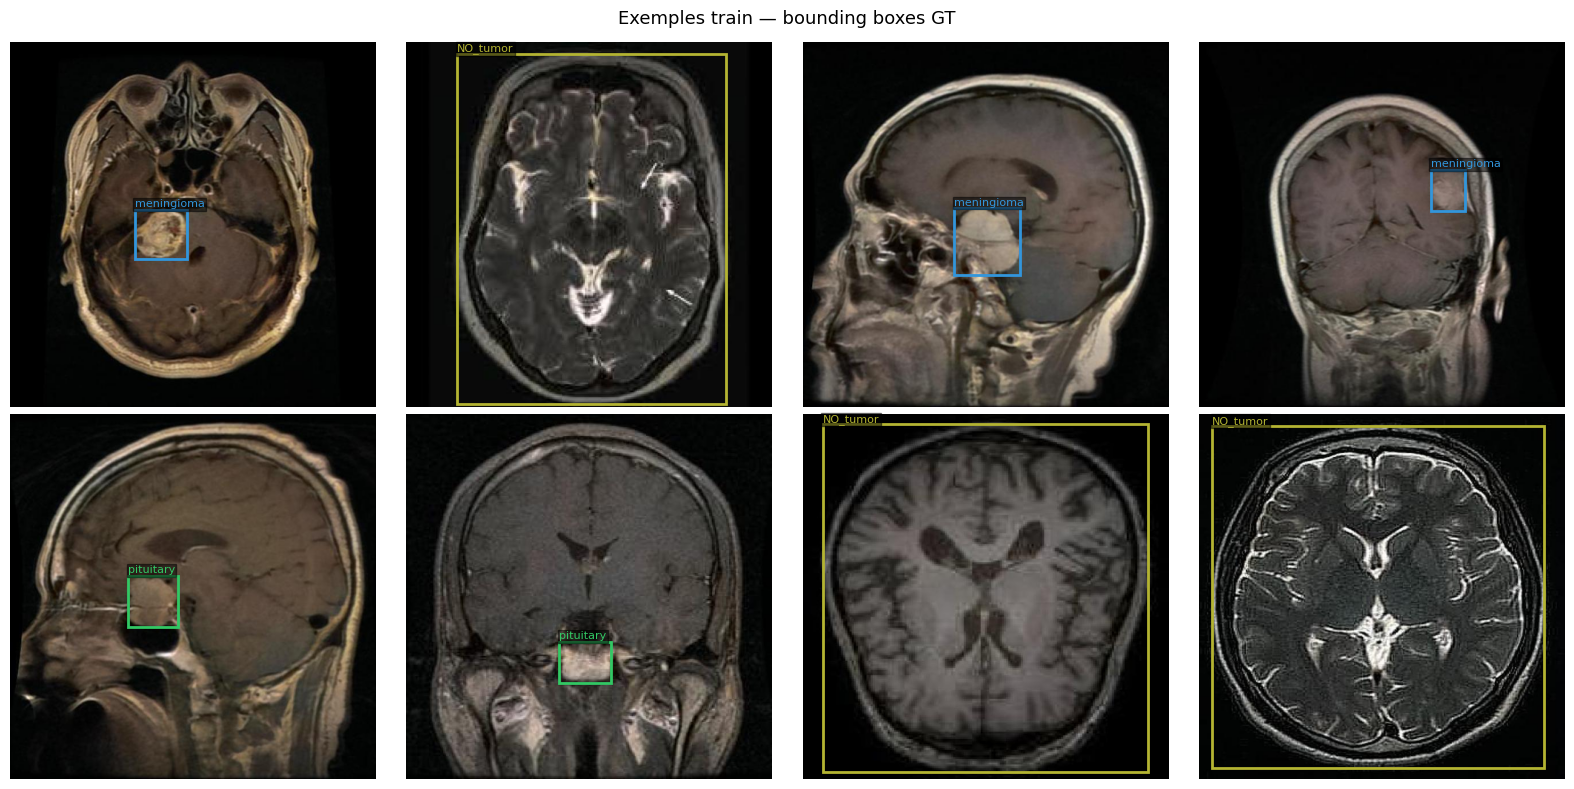

In [ ]:
# ── Visualisation de quelques images annotées ────────────────────────────────
COLORS_VIS = [(220,50,50),(50,150,220),(50,200,100),(180,180,50),(200,50,200)]

def show_samples(split='train', n=8):
    csv_path = DATA_DIR / split / '_annotations.csv'
    records  = {}
    with open(csv_path) as f:
        for row in csv.DictReader(f):
            records.setdefault(row['filename'], []).append(row)
    fnames = random.sample(list(records.keys()), min(n, len(records)))
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    for ax, fname in zip(axes.flatten(), fnames):
        img = cv2.cvtColor(cv2.imread(str(DATA_DIR / split / fname)), cv2.COLOR_BGR2RGB)
        ax.imshow(img)
        for r in records[fname]:
            cls = CLASS_MAP.get(r['class'], -1)
            if cls == -1: continue
            x1,y1,x2,y2 = float(r['xmin']),float(r['ymin']),float(r['xmax']),float(r['ymax'])
            color = tuple(c/255 for c in COLORS_VIS[cls])
            ax.add_patch(patches.Rectangle((x1,y1),x2-x1,y2-y1,
                         linewidth=2, edgecolor=color, facecolor='none'))
            ax.text(x1, y1-4, r['class'], fontsize=8, color=color,
                    bbox=dict(facecolor='black', alpha=0.5, pad=1))
        ax.axis('off')
    plt.suptitle(f'Exemples {split} — bounding boxes GT', fontsize=13)
    plt.tight_layout(); plt.show()

show_samples('train', 8)

## 3 — Architecture NeuroDetect
### 3.1 Modules de base (CBAM, MSDCM, BiFPN, AMN)

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# MODULES DE BASE
# ════════════════════════════════════════════════════════════════════════════

class ConvBNAct(nn.Module):
    """Conv → BatchNorm → SiLU"""
    def __init__(self, in_c, out_c, k=3, s=1, p=None, g=1, act=True):
        super().__init__()
        p = k // 2 if p is None else p
        self.conv = nn.Conv2d(in_c, out_c, k, s, p, groups=g, bias=False)
        self.bn   = nn.BatchNorm2d(out_c)
        self.act  = nn.SiLU(inplace=True) if act else nn.Identity()
    def forward(self, x): return self.act(self.bn(self.conv(x)))


class DWConv(nn.Module):
    """Convolution depth-wise séparable"""
    def __init__(self, in_c, out_c, k=3, s=1):
        super().__init__()
        self.dw = ConvBNAct(in_c, in_c, k, s, g=in_c)
        self.pw = ConvBNAct(in_c, out_c, 1, 1)
    def forward(self, x): return self.pw(self.dw(x))


# ── ① AdaptiveMRINorm ────────────────────────────────────────────────────────
class AdaptiveMRINorm(nn.Module):
    """
    InstanceNorm apprenante appliquée à l'image d'entrée.
    Compense la variabilité d'intensité caractéristique de l'IRM
    (scanner-à-scanner, protocoles différents, variabilité patient).
    Les paramètres affines γ, β sont appris end-to-end.
    """
    def __init__(self, c=3):
        super().__init__()
        self.norm = nn.InstanceNorm2d(c, affine=True)
    def forward(self, x): return self.norm(x)


# ── ② CBAM : Channel + Spatial Attention ────────────────────────────────────
class ChannelAttn(nn.Module):
    def __init__(self, c, r=16):
        super().__init__()
        mid = max(c // r, 1)
        self.mlp = nn.Sequential(
            nn.Conv2d(c, mid, 1, bias=False), nn.ReLU(inplace=True),
            nn.Conv2d(mid, c, 1, bias=False))
    def forward(self, x):
        a = self.mlp(F.adaptive_avg_pool2d(x, 1))
        m = self.mlp(F.adaptive_max_pool2d(x, 1))
        return x * torch.sigmoid(a + m)

class SpatialAttn(nn.Module):
    def __init__(self, k=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, k, padding=k//2, bias=False)
    def forward(self, x):
        avg = x.mean(1, keepdim=True)
        mx,_ = x.max(1, keepdim=True)
        return x * torch.sigmoid(self.conv(torch.cat([avg, mx], 1)))

class CBAM(nn.Module):
    """
    Convolutional Block Attention Module.
    Force le backbone à se concentrer d'abord sur les canaux pertinents
    (texture tumorale), puis sur leur localisation spatiale.
    Particulièrement utile quand la tumeur occupe une faible fraction de la coupe IRM.
    """
    def __init__(self, c, r=16, k=7):
        super().__init__()
        self.ca = ChannelAttn(c, r)
        self.sa = SpatialAttn(k)
    def forward(self, x): return self.sa(self.ca(x))


# ── ③ MSDCM : Multi-Scale Dilated Context Module ─────────────────────────────
class MSDCM(nn.Module):
    """
    Convolutions dilatées parallèles (d=1,3,5,7).
    - d=1 : texture locale (bord net)
    - d=7 : contexte anatomique large (bord diffus, flou)
    Résidu pour ne pas perdre d'information.
    → Critique pour les tumeurs IRM aux bords imprécis.
    """
    def __init__(self, c):
        super().__init__()
        mid = c // 4
        mk = lambda d: nn.Sequential(
            nn.Conv2d(c, mid, 3, padding=d, dilation=d, bias=False),
            nn.BatchNorm2d(mid), nn.SiLU(inplace=True))
        self.b1, self.b2, self.b3, self.b4 = mk(1), mk(3), mk(5), mk(7)
        self.fuse = nn.Sequential(
            nn.Conv2d(mid*4, c, 1, bias=False),
            nn.BatchNorm2d(c), nn.SiLU(inplace=True))
    def forward(self, x):
        return self.fuse(torch.cat(
            [self.b1(x), self.b2(x), self.b3(x), self.b4(x)], 1)) + x


# ── ④ BiFPN Block ─────────────────────────────────────────────────────────────
class BiFPNBlock(nn.Module):
    """
    Un bloc BiFPN avec fusion pondérée rapide (poids appris par niveau).
    Avantage sur PANet (YOLOv8) : flux TOP-DOWN + BOTTOM-UP dans le même bloc,
    avec des poids appris indépendants pour chaque connexion.
    """
    def __init__(self, c=128, n=3, eps=1e-4):
        super().__init__()
        self.eps = eps
        self.td_w = nn.ParameterList([nn.Parameter(torch.ones(2)) for _ in range(n-1)])
        self.bu_w = nn.ParameterList([nn.Parameter(torch.ones(3)) for _ in range(n-1)])
        self.td_c = nn.ModuleList([ConvBNAct(c, c) for _ in range(n-1)])
        self.bu_c = nn.ModuleList([ConvBNAct(c, c) for _ in range(n-1)])

    def _fuse(self, w, *ts):
        w = F.relu(w); w = w / (w.sum() + self.eps)
        return sum(w[i] * t for i, t in enumerate(ts))

    def forward(self, feats):
        P = list(feats); n = len(P)
        # Top-down
        td = [None]*n; td[-1] = P[-1]
        for i in range(n-2, -1, -1):
            up = F.interpolate(td[i+1], size=P[i].shape[2:], mode='nearest')
            td[i] = self.td_c[i](self._fuse(self.td_w[i], P[i], up))
        # Bottom-up
        out = [None]*n; out[0] = td[0]
        for i in range(1, n):
            dn = F.adaptive_max_pool2d(out[i-1], P[i].shape[2:])
            out[i] = self.bu_c[i-1](self._fuse(self.bu_w[i-1], P[i], td[i], dn))
        return out


print('✓ Modules de base définis : ConvBNAct, DWConv, AdaptiveMRINorm, CBAM, MSDCM, BiFPNBlock')

✓ Modules de base définis : ConvBNAct, DWConv, AdaptiveMRINorm, CBAM, MSDCM, BiFPNBlock


### 3.2 Backbone — EfficientNet-B3 + CBAM

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# BACKBONE : EfficientNet-B3 + CBAM
# ════════════════════════════════════════════════════════════════════════════
# Canaux EfficientNet-B3 (timm, indices 2/3/4) :
#   P3 (stride  8) : 48  canaux
#   P4 (stride 16) : 136 canaux
#   P5 (stride 32) : 384 canaux
#
# Pourquoi EfficientNet vs CSPDarknet (YOLOv8) ?
#   - Compound scaling optimisé : profondeur + largeur + résolution co-optimisés
#   - Meilleure accuracy ImageNet → représentations plus riches pour le transfert IRM
#   - SE blocks intégrés (attention canal légère) + CBAM en sortie = double attention

class MedBackbone(nn.Module):
    def __init__(self, name='efficientnet_b3', pretrained=True):
        super().__init__()
        self.encoder = timm.create_model(
            name, pretrained=pretrained,
            features_only=True, out_indices=(2, 3, 4))
        ch = self.encoder.feature_info.channels()   # [48, 136, 384]
        self.cbam3 = CBAM(ch[0])
        self.cbam4 = CBAM(ch[1])
        self.cbam5 = CBAM(ch[2])
        self._ch = ch

    @property
    def out_channels(self): return self._ch

    def forward(self, x):
        f3, f4, f5 = self.encoder(x)
        return self.cbam3(f3), self.cbam4(f4), self.cbam5(f5)


# Test rapide
_bb = MedBackbone(pretrained=False)
_x  = torch.randn(1, 3, 640, 640)
_f3, _f4, _f5 = _bb(_x)
print(f'Backbone sorties :')
print(f'  P3 : {tuple(_f3.shape)}  (stride 8)')
print(f'  P4 : {tuple(_f4.shape)}  (stride 16)')
print(f'  P5 : {tuple(_f5.shape)}  (stride 32)')
print('✓ Backbone OK')

Backbone sorties :
  P3 : (1, 48, 80, 80)  (stride 8)
  P4 : (1, 136, 40, 40)  (stride 16)
  P5 : (1, 384, 20, 20)  (stride 32)
✓ Backbone OK


### 3.3 Neck — BiFPN × 2 + MSDCM

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# NECK : BiFPN × repeats + MSDCM par niveau
# ════════════════════════════════════════════════════════════════════════════
# Pipeline :
#   [P3,P4,P5] → projection 1×1 → BiFPN×N → MSDCM×3 → [P3',P4',P5']
#
# MSDCM en sortie : chaque cellule de la feature map dispose d'un contexte
# allant de 3×3 (dilation 1) à 15×15 pixels effectifs (dilation 7).

class MedNeck(nn.Module):
    def __init__(self, in_channels, fpn_c=128, repeats=2):
        super().__init__()
        self.lat3 = ConvBNAct(in_channels[0], fpn_c, 1, p=0)
        self.lat4 = ConvBNAct(in_channels[1], fpn_c, 1, p=0)
        self.lat5 = ConvBNAct(in_channels[2], fpn_c, 1, p=0)
        self.bifpn = nn.ModuleList([BiFPNBlock(fpn_c) for _ in range(repeats)])
        self.ctx3  = MSDCM(fpn_c)
        self.ctx4  = MSDCM(fpn_c)
        self.ctx5  = MSDCM(fpn_c)
        self.out_c = fpn_c

    def forward(self, feats):
        p3, p4, p5 = feats
        p3, p4, p5 = self.lat3(p3), self.lat4(p4), self.lat5(p5)
        fs = [p3, p4, p5]
        for blk in self.bifpn:
            fs = blk(fs)
        p3, p4, p5 = fs
        return self.ctx3(p3), self.ctx4(p4), self.ctx5(p5)


_neck = MedNeck(_bb.out_channels, fpn_c=128, repeats=2)
_n3, _n4, _n5 = _neck((_f3, _f4, _f5))
print(f'Neck sorties :')
print(f'  P3\' : {tuple(_n3.shape)}')
print(f'  P4\' : {tuple(_n4.shape)}')
print(f'  P5\' : {tuple(_n5.shape)}')
print('✓ Neck OK')

Neck sorties :
  P3' : (1, 128, 80, 80)
  P4' : (1, 128, 40, 40)
  P5' : (1, 128, 20, 20)
✓ Neck OK


### 3.4 Tête de détection découplée (Anchor-Free LTRB)

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# TÊTE DE DÉTECTION DÉCOUPLÉE
# ════════════════════════════════════════════════════════════════════════════
# Formulation LTRB anchor-free :
#   Pour la cellule (j, i) au stride s :
#     l, t, r, b = exp(raw) × s   [pixels depuis le centre de la cellule]
#     x1 = j×s + s/2 − l  ,  y1 = i×s + s/2 − t
#     x2 = j×s + s/2 + r  ,  y2 = i×s + s/2 + b
#
# Branche cls  : 2×DWConv → Conv(nc,1)  → sigmoid  [pas d'objectness]
# Branche box  : 2×DWConv → Conv(4,1)   → exp×stride

class DetHead(nn.Module):
    def __init__(self, in_c, nc, strides=(8,16,32)):
        super().__init__()
        self.nc      = nc
        self.strides = strides
        self.cls_b   = nn.ModuleList()
        self.box_b   = nn.ModuleList()
        self.cls_p   = nn.ModuleList()
        self.box_p   = nn.ModuleList()
        for _ in strides:
            self.cls_b.append(nn.Sequential(DWConv(in_c,in_c), DWConv(in_c,in_c)))
            self.box_b.append(nn.Sequential(DWConv(in_c,in_c), DWConv(in_c,in_c)))
            self.cls_p.append(nn.Conv2d(in_c, nc, 1))
            self.box_p.append(nn.Conv2d(in_c, 4,  1))
        self._init_biases()

    def _init_biases(self):
        bias = -math.log(99)   # prior 0.01
        for c in self.cls_p: nn.init.constant_(c.bias, bias)

    def forward(self, feats):
        cls_list, box_list = [], []
        for i, f in enumerate(feats):
            cls_list.append(self.cls_p[i](self.cls_b[i](f)))
            box_list.append(self.box_p[i](self.box_b[i](f)))
        return cls_list, box_list

    @torch.no_grad()
    def decode(self, cls_list, box_list, img_size=640):
        """Retourne (B, total_cells, 4+nc) — xyxy en pixels + scores sigmoid"""
        out = []
        for i, (cls, box) in enumerate(zip(cls_list, box_list)):
            s = self.strides[i]
            B, _, H, W = cls.shape
            dev = cls.device
            gy, gx = torch.meshgrid(
                torch.arange(H, device=dev), torch.arange(W, device=dev),
                indexing='ij')
            cx = (gx.float() + .5) * s
            cy = (gy.float() + .5) * s
            ltrb = torch.exp(box.clamp(-4,4)) * s
            l,t,r,b = ltrb[:,0],ltrb[:,1],ltrb[:,2],ltrb[:,3]
            xyxy = torch.stack([
                (cx-l).clamp(0,img_size), (cy-t).clamp(0,img_size),
                (cx+r).clamp(0,img_size), (cy+b).clamp(0,img_size)], -1)
            xyxy     = xyxy.reshape(B, H*W, 4)
            cls_prob = cls.sigmoid().permute(0,2,3,1).reshape(B, H*W, self.nc)
            out.append(torch.cat([xyxy, cls_prob], -1))
        return torch.cat(out, 1)   # (B, 8400, 4+nc)


_head = DetHead(128, NC)
_cl, _bl = _head([_n3, _n4, _n5])
_dec = _head.decode(_cl, _bl, 640)
print(f'Head sorties :')
for i,(c,b) in enumerate(zip(_cl,_bl)):
    print(f'  P{i+3}: cls={tuple(c.shape)}, box={tuple(b.shape)}')
print(f'Décodé : {tuple(_dec.shape)}  (B, 8400 cellules, 4+{NC})')
print('✓ Tête OK')

Head sorties :
  P3: cls=(1, 5, 80, 80), box=(1, 4, 80, 80)
  P4: cls=(1, 5, 40, 40), box=(1, 4, 40, 40)
  P5: cls=(1, 5, 20, 20), box=(1, 4, 20, 20)
Décodé : (1, 8400, 9)  (B, 8400 cellules, 4+5)
✓ Tête OK


### 3.5 Assemblage du modèle complet — NeuroDetect

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# MODÈLE COMPLET : NeuroDetect
# ════════════════════════════════════════════════════════════════════════════

class NeuroDetect(nn.Module):
    def __init__(self, nc=5, backbone='efficientnet_b3',
                 fpn_c=128, bifpn_rep=2, strides=(8,16,32), pretrained=True):
        super().__init__()
        self.nc      = nc
        self.strides = strides
        self.amn      = AdaptiveMRINorm(3)
        self.backbone = MedBackbone(backbone, pretrained)
        self.neck     = MedNeck(self.backbone.out_channels, fpn_c, bifpn_rep)
        self.head     = DetHead(fpn_c, nc, strides)

    def forward(self, x):
        x = self.amn(x)
        x = self.backbone(x)
        x = self.neck(x)
        return self.head(x)            # (cls_list, box_list)

    @torch.no_grad()
    def predict(self, x, img_size=640):
        self.eval()
        cls_list, box_list = self.forward(x)
        return self.head.decode(cls_list, box_list, img_size)

    def n_params(self):
        return sum(p.numel() for p in self.parameters())


# ── Résumé du modèle ─────────────────────────────────────────────────────────
model = NeuroDetect(nc=NC, pretrained=True).to(DEVICE)
print(f'NeuroDetect — {model.n_params()/1e6:.2f}M paramètres')
print(f'Composants :')
print(f'  AMN      : {sum(p.numel() for p in model.amn.parameters()):>8,}')
print(f'  Backbone : {sum(p.numel() for p in model.backbone.parameters()):>8,}')
print(f'  Neck     : {sum(p.numel() for p in model.neck.parameters()):>8,}')
print(f'  Head     : {sum(p.numel() for p in model.head.parameters()):>8,}')

# Test forward GPU
_x = torch.randn(2, 3, 640, 640).to(DEVICE)
_c, _b = model(_x)
print(f'\nForward GPU OK — VRAM utilisée : {torch.cuda.memory_allocated(DEVICE)/1024**2:.0f} MB')

model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

NeuroDetect — 12.09M paramètres
Composants :
  AMN      :        6
  Backbone : 10,124,526
  Neck     : 1,748,244
  Head     :  220,059

Forward GPU OK — VRAM utilisée : 3116 MB


## 4 — Dataset & Augmentations IRM

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# DATASET & AUGMENTATIONS
# ════════════════════════════════════════════════════════════════════════════

def load_csv(csv_path):
    """Retourne dict {filename → [[cls, x1, y1, x2, y2], ...]}"""
    rec = {}
    with open(csv_path) as f:
        for r in csv.DictReader(f):
            cls = CLASS_MAP.get(r['class'], -1)
            if cls == -1: continue
            rec.setdefault(r['filename'], []).append(
                [cls, float(r['xmin']), float(r['ymin']),
                      float(r['xmax']), float(r['ymax'])])
    return rec

def xyxy2cxcywh(x1,y1,x2,y2,W,H):
    return (x1+x2)/2/W, (y1+y2)/2/H, (x2-x1)/W, (y2-y1)/H

def build_transform(img_size, is_train):
    if not HAS_ALB:
        return None
    if not is_train:
        return A.Compose(
            [A.Resize(img_size, img_size), A.Normalize(), ToTensorV2()],
            bbox_params=A.BboxParams('pascal_voc', label_fields=['labels'],
                                      min_visibility=0.1))
    return A.Compose([
        A.Resize(img_size, img_size),
        # ── Augmentations spécifiques IRM ──────────────────────────────
        A.RandomBrightnessContrast(brightness_limit=0.3,
                                    contrast_limit=0.3, p=0.6),
        A.RandomGamma(gamma_limit=(70,130), p=0.4),
        A.ElasticTransform(alpha=50, sigma=5, p=0.3),
        # ── Augmentations géométriques standard ────────────────────────
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.1),
        A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.5,
                            rotate_limit=10, p=0.5),
        A.Normalize(), ToTensorV2(),
    ], bbox_params=A.BboxParams('pascal_voc', label_fields=['labels'],
                                 min_visibility=0.1))


class BrainDataset(Dataset):
    def __init__(self, csv_path, img_dir, img_size=640, is_train=True,
                 mosaic_p=0.5):
        self.img_dir   = Path(img_dir)
        self.img_size  = img_size
        self.is_train  = is_train
        self.mosaic_p  = mosaic_p if is_train else 0.
        self.records   = load_csv(csv_path)
        self.fnames    = list(self.records.keys())
        self.tf        = build_transform(img_size, is_train)

    def __len__(self): return len(self.fnames)

    def _read(self, fname):
        img = cv2.cvtColor(
            cv2.imread(str(self.img_dir / fname)), cv2.COLOR_BGR2RGB)
        if img is None:
            img = np.zeros((self.img_size, self.img_size, 3), np.uint8)
        return img

    def _augment(self, img, boxes, lbls):
        if self.tf is not None:
            r = self.tf(image=img, bboxes=boxes, labels=lbls)
            img_t = r['image']
            boxes, lbls = r['bboxes'], r['labels']
        else:
            img_t = torch.from_numpy(
                cv2.resize(img,(self.img_size,self.img_size)
                ).transpose(2,0,1)).float()/255.
        s = self.img_size
        tgt = [[float(c),*xyxy2cxcywh(x1,y1,x2,y2,s,s)]
               for (x1,y1,x2,y2),c in zip(boxes,lbls)
               if (x2-x1)>0 and (y2-y1)>0]
        return img_t, tgt

    def _mosaic(self, idx):
        s  = self.img_size
        yc = random.randint(s//4, 3*s//4)
        xc = random.randint(s//4, 3*s//4)
        idxs = [idx] + random.choices(range(len(self)), k=3)
        canvas = np.zeros((s,s,3), np.uint8)
        labels = []
        for pos, i in zip([(0,0,xc,yc),(xc,0,s,yc),
                            (0,yc,xc,s),(xc,yc,s,s)], idxs):
            x1p,y1p,x2p,y2p = pos
            pw,ph = x2p-x1p, y2p-y1p
            fn  = self.fnames[i]
            img = cv2.resize(self._read(fn),(pw,ph))
            canvas[y1p:y2p, x1p:x2p] = img
            for b in self.records[fn]:
                cls,bx1,by1,bx2,by2 = b
                sx,sy = pw/s, ph/s
                nx1=bx1*sx+x1p; ny1=by1*sy+y1p
                nx2=bx2*sx+x1p; ny2=by2*sy+y1p
                nx1,nx2=max(0,nx1),min(s,nx2)
                ny1,ny2=max(0,ny1),min(s,ny2)
                if nx2-nx1>2 and ny2-ny1>2:
                    labels.append([float(cls),
                                   *xyxy2cxcywh(nx1,ny1,nx2,ny2,s,s)])
        return canvas, labels

    def __getitem__(self, idx):
        fn = self.fnames[idx]
        if self.is_train and random.random() < self.mosaic_p:
            img, labels = self._mosaic(idx)
            img_t = torch.from_numpy(
                img.transpose(2,0,1)).float()/255.
        else:
            img  = self._read(fn)
            raw  = self.records[fn]
            boxes = [[b[1],b[2],b[3],b[4]] for b in raw]
            lbls  = [int(b[0]) for b in raw]
            img_t, labels = self._augment(img, boxes, lbls)
        tgt = (torch.tensor(labels, dtype=torch.float32)
               if labels else torch.zeros(0,5))
        return img_t, tgt


def collate(batch):
    imgs, tgts = zip(*batch)
    imgs = torch.stack(imgs, 0)
    out  = []
    for i, t in enumerate(tgts):
        if len(t):
            out.append(torch.cat([torch.full((len(t),1),i), t], 1))
    tgts = torch.cat(out,0) if out else torch.zeros(0,6)
    return imgs, tgts


def make_loader(split, is_train, batch_size=8, num_workers=2):
    ds = BrainDataset(
        csv_path=str(DATA_DIR/split/'_annotations.csv'),
        img_dir =str(DATA_DIR/split),
        is_train=is_train,
        mosaic_p=0.5 if is_train else 0.)
    return DataLoader(ds, batch_size=batch_size, shuffle=is_train,
                      num_workers=num_workers, pin_memory=True,
                      collate_fn=collate, drop_last=is_train)


# Test
_ds = BrainDataset(str(DATA_DIR/'train'/'_annotations.csv'),
                    str(DATA_DIR/'train'), is_train=False)
_img, _tgt = _ds[0]
print(f'Sample image : {tuple(_img.shape)}, dtype={_img.dtype}')
print(f'Sample labels: {tuple(_tgt.shape)}  [cls, cx, cy, w, h]')
print('✓ Dataset OK')

Sample image : (3, 640, 640), dtype=torch.float32
Sample labels: (1, 5)  [cls, cx, cy, w, h]
✓ Dataset OK


## 5 — Fonctions de perte (AsymFocal + CIoU + SimOTA)

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# FONCTIONS DE PERTE
# ════════════════════════════════════════════════════════════════════════════

# ── CIoU Loss ────────────────────────────────────────────────────────────────
def ciou_loss(p, g):
    """p, g : (N,4) xyxy pixels → CIoU loss scalaire"""
    eps  = 1e-7
    px1,py1,px2,py2 = p.unbind(-1)
    gx1,gy1,gx2,gy2 = g.unbind(-1)
    pcx,pcy = (px1+px2)/2,(py1+py2)/2
    gcx,gcy = (gx1+gx2)/2,(gy1+gy2)/2
    pw,ph   = (px2-px1).clamp(eps),(py2-py1).clamp(eps)
    gw,gh   = (gx2-gx1).clamp(eps),(gy2-gy1).clamp(eps)
    ix1,iy1 = torch.max(px1,gx1),torch.max(py1,gy1)
    ix2,iy2 = torch.min(px2,gx2),torch.min(py2,gy2)
    inter   = (ix2-ix1).clamp(0)*(iy2-iy1).clamp(0)
    iou     = inter/(pw*ph+gw*gh-inter+eps)
    d2      = (pcx-gcx)**2+(pcy-gcy)**2
    c2      = ((torch.min(px1,gx1)-torch.max(px2,gx2))**2 +
               (torch.min(py1,gy1)-torch.max(py2,gy2))**2 + eps)
    v       = (4/math.pi**2)*(torch.atan(gw/gh)-torch.atan(pw/ph))**2
    with torch.no_grad(): alpha = v/(1-iou+v+eps)
    return (1-iou+d2/c2+alpha*v).mean()


# ── Asymmetric Focal Loss ─────────────────────────────────────────────────────
class AsymFocalLoss(nn.Module):
    """
    Asymmetric Focal Loss (Ridnik et al., 2021) adapté pour l'IRM.

    Positifs : -(1-p)^γ⁺ · log(p)          [γ⁺=0 → pas de down-weighting]
    Négatifs : -(p')^γ⁻ · log(1-p')         [γ⁻=4 → supprime les négatifs faciles]
      avec p' = max(0, p − margin)

    Intérêt médical :
      γ⁺=0  → tous les positifs contribuent également (manquer une tumeur = catastrophe)
      γ⁻=4  → les cellules background évidentes sont fortement supprimées
      margin → shift des probabilités négatives réduit les faux positifs
    """
    def __init__(self, gp=0., gn=4., margin=0.05, class_w=None):
        super().__init__()
        self.gp = gp; self.gn = gn; self.m = margin
        self.register_buffer('cw',
            class_w if class_w is not None else torch.ones(1))

    def forward(self, logits, targets):
        p   = torch.sigmoid(logits)
        pt  = torch.where(targets==1, p, 1-p)
        fw  = torch.where(targets==1,
                          (1-p)**self.gp,
                          torch.clamp(p-self.m, min=0)**self.gn)
        loss = -fw * torch.log(pt.clamp(1e-8))
        if self.cw.numel()>1:
            loss = loss * self.cw.to(loss.device)
        return loss.mean()


# ── SimOTA Assignment ─────────────────────────────────────────────────────────
@torch.no_grad()
def simota(pred_boxes, pred_cls, gt_boxes, gt_cls, topk=13):
    """
    Assigne les GT aux cellules les plus pertinentes.
    Retourne (pos_mask, matched_gt_idx).
    """
    dev = pred_boxes.device
    N, G = pred_boxes.shape[0], gt_boxes.shape[0]
    nc   = pred_cls.shape[1]
    if G == 0:
        return (torch.zeros(N,dtype=torch.bool,device=dev),
                torch.full((N,),-1,dtype=torch.long,device=dev))

    cx = (pred_boxes[:,0]+pred_boxes[:,2])/2
    cy = (pred_boxes[:,1]+pred_boxes[:,3])/2
    in_gt = ((cx[:,None]>=gt_boxes[None,:,0]) & (cx[:,None]<=gt_boxes[None,:,2]) &
             (cy[:,None]>=gt_boxes[None,:,1]) & (cy[:,None]<=gt_boxes[None,:,3]))

    # IoU matrix (N,G)
    pb = pred_boxes[:,None].expand(N,G,4)
    gb = gt_boxes[None].expand(N,G,4)
    ix1=torch.max(pb[...,0],gb[...,0]); iy1=torch.max(pb[...,1],gb[...,1])
    ix2=torch.min(pb[...,2],gb[...,2]); iy2=torch.min(pb[...,3],gb[...,3])
    inter=(ix2-ix1).clamp(0)*(iy2-iy1).clamp(0)
    a1=(pb[...,2]-pb[...,0])*(pb[...,3]-pb[...,1])
    a2=(gb[...,2]-gb[...,0])*(gb[...,3]-gb[...,1])
    iou_mat=inter/(a1+a2-inter+1e-7)

    oh = F.one_hot(gt_cls, nc).float().unsqueeze(0).expand(N,G,nc)
    pp = pred_cls.sigmoid().unsqueeze(1).expand(N,G,nc)
    cost = -(oh*pp).sum(-1) - iou_mat
    cost[~in_gt] = 1e6

    matched_gt = torch.full((N,),-1,dtype=torch.long,device=dev)
    pos_mask   = torch.zeros(N,dtype=torch.bool,device=dev)
    for g in range(G):
        k = max(1, min(topk, int((iou_mat[:,g]>0.5).sum().item())))
        _, idx = cost[:,g].topk(k, largest=False)
        valid  = in_gt[idx, g]
        idx    = idx[valid]
        pos_mask[idx]   = True
        matched_gt[idx] = g
    return pos_mask, matched_gt


# ── Perte complète ────────────────────────────────────────────────────────────
class NeuroDetLoss(nn.Module):
    def __init__(self, nc=5, strides=(8,16,32), img_size=640,
                 box_w=7.5, cls_w=0.5,
                 gp=0., gn=4., margin=0.05, class_w=None):
        super().__init__()
        self.nc=nc; self.strides=strides; self.img_size=img_size
        self.box_w=box_w; self.cls_w=cls_w
        self.cls_loss=AsymFocalLoss(gp,gn,margin,class_w)

    def _decode_boxes(self, box, s, H, W, dev):
        gy,gx=torch.meshgrid(torch.arange(H,device=dev),
                              torch.arange(W,device=dev),indexing='ij')
        cx=(gx.float()+.5)*s; cy=(gy.float()+.5)*s
        ltrb=torch.exp(box.clamp(-4,4))*s
        l,t,r,b=ltrb[:,0],ltrb[:,1],ltrb[:,2],ltrb[:,3]
        xyxy=torch.stack([(cx-l).clamp(0,self.img_size),
                          (cy-t).clamp(0,self.img_size),
                          (cx+r).clamp(0,self.img_size),
                          (cy+b).clamp(0,self.img_size)],-1)
        return xyxy.reshape(box.shape[0],-1,4)

    def forward(self, cls_list, box_list, targets):
        dev=cls_list[0].device; B=cls_list[0].shape[0]
        all_cls,all_box=[],[]
        for i,(cls,box) in enumerate(zip(cls_list,box_list)):
            s=self.strides[i]; _,nc,H,W=cls.shape
            all_cls.append(cls.permute(0,2,3,1).reshape(B,-1,nc))
            all_box.append(self._decode_boxes(box,s,H,W,dev))
        all_cls=torch.cat(all_cls,1); all_box=torch.cat(all_box,1)

        loss=torch.tensor(0.,device=dev,requires_grad=True)
        cls_l_tot=box_l_tot=torch.tensor(0.,device=dev)
        n_pos=0
        for bi in range(B):
            mask=targets[:,0]==bi; tgt=targets[mask]
            if len(tgt)==0: continue
            gt_cls=tgt[:,1].long()
            gt_cx,gt_cy=tgt[:,2]*self.img_size,tgt[:,3]*self.img_size
            gt_w,gt_h  =tgt[:,4]*self.img_size,tgt[:,5]*self.img_size
            gt_xyxy=torch.stack([gt_cx-gt_w/2,gt_cy-gt_h/2,
                                  gt_cx+gt_w/2,gt_cy+gt_h/2],-1)
            pos,mgt=simota(all_box[bi],all_cls[bi],gt_xyxy,gt_cls)
            if not pos.any(): continue
            # Cls loss
            oh=torch.zeros_like(all_cls[bi])
            for k in pos.nonzero(as_tuple=False).squeeze(1):
                oh[k,gt_cls[mgt[k]]]=1.
            cl=self.cls_loss(all_cls[bi],oh)
            # Box loss
            pi=pos.nonzero(as_tuple=False).squeeze(1)
            bl=ciou_loss(all_box[bi][pi],gt_xyxy[mgt[pi]])
            n_pos+=pi.shape[0]
            cls_l_tot=cls_l_tot+cl; box_l_tot=box_l_tot+bl
        if n_pos>0:
            loss=self.cls_w*cls_l_tot+self.box_w*box_l_tot
        return loss,{'cls':cls_l_tot.item(),'box':box_l_tot.item(),'n_pos':n_pos}


# Test de la perte
_loader = DataLoader(
    BrainDataset(str(DATA_DIR/'train'/'_annotations.csv'),
                  str(DATA_DIR/'train'), is_train=False),
    batch_size=2, collate_fn=collate, num_workers=0)
_imgs, _tgts = next(iter(_loader))
_imgs, _tgts = _imgs.to(DEVICE), _tgts.to(DEVICE)
_cw = torch.tensor([3., 1., 1.5, 0.8, 5.], device=DEVICE)
_crit = NeuroDetLoss(NC, class_w=_cw).to(DEVICE)
_cl_l, _bx_l = model(_imgs)
_loss, _d = _crit(_cl_l, _bx_l, _tgts)
print(f'Loss test — total={_loss.item():.4f}  cls={_d["cls"]:.4f}  '
      f'box={_d["box"]:.4f}  n_pos={_d["n_pos"]}')
print('✓ Loss OK')

Loss test — total=8.6258  cls=0.0012  box=1.1500  n_pos=4
✓ Loss OK


## 6 — Post-processing (NMS) & Métriques (mAP)

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# NMS
# ════════════════════════════════════════════════════════════════════════════

def nms(preds, conf=0.25, iou_t=0.45, max_det=300):
    """
    preds : (B, total, 4+nc)  xyxy + scores
    → liste de B tenseurs (D,6) : [x1,y1,x2,y2,score,cls]
    """
    out = []
    for b in range(preds.shape[0]):
        p = preds[b]
        scores, cls_idx = p[:,4:].max(1)
        mask = scores > conf
        p, scores, cls_idx = p[mask], scores[mask], cls_idx[mask]
        if not len(p):
            out.append(torch.zeros(0,6)); continue
        boxes = p[:,:4]
        try:
            from torchvision.ops import batched_nms
            keep = batched_nms(boxes, scores, cls_idx, iou_t)
        except Exception:
            keep = _greedy_nms(boxes, scores, iou_t)
        keep = keep[:max_det]
        out.append(torch.cat([boxes[keep], scores[keep,None],
                               cls_idx[keep].float()[:,None]], 1))
    return out

def _iou1(b, bs):
    ix1=bs[:,0].clamp(min=b[0]); iy1=bs[:,1].clamp(min=b[1])
    ix2=bs[:,2].clamp(max=b[2]); iy2=bs[:,3].clamp(max=b[3])
    i=(ix2-ix1).clamp(0)*(iy2-iy1).clamp(0)
    a1=(b[2]-b[0])*(b[3]-b[1])
    a2=(bs[:,2]-bs[:,0])*(bs[:,3]-bs[:,1])
    return i/(a1+a2-i+1e-7)

def _greedy_nms(boxes, scores, iou_t):
    order = scores.argsort(descending=True); keep=[]
    while order.numel():
        i=order[0].item(); keep.append(i)
        if order.numel()==1: break
        order=order[1:][_iou1(boxes[i],boxes[order[1:]])<=iou_t]
    return torch.tensor(keep,dtype=torch.long)


# ════════════════════════════════════════════════════════════════════════════
# mAP
# ════════════════════════════════════════════════════════════════════════════

def _iou_np(a,b):
    x1=max(a[0],b[0]);y1=max(a[1],b[1]);x2=min(a[2],b[2]);y2=min(a[3],b[3])
    i=max(0,x2-x1)*max(0,y2-y1)
    return i/((a[2]-a[0])*(a[3]-a[1])+(b[2]-b[0])*(b[3]-b[1])-i+1e-7)

def _voc_ap(rec,prec):
    mr=np.concatenate([[0.],rec,[1.]]); mp=np.concatenate([[0.],prec,[0.]])
    for i in range(mp.size-1,0,-1): mp[i-1]=max(mp[i-1],mp[i])
    idx=np.where(mr[1:]!=mr[:-1])[0]
    return float(np.sum((mr[idx+1]-mr[idx])*mp[idx+1]))

def compute_map(predictions, gt_tensor, nc=5, img_size=640):
    """
    predictions : liste de tenseurs (D,6)
    gt_tensor   : (T,6) [img_idx,cls,cx,cy,w,h] normalisé
    """
    gt_by_img = defaultdict(list)
    if gt_tensor is not None and len(gt_tensor):
        for r in gt_tensor:
            bi=int(r[0]); cls=int(r[1])
            cx,cy=r[2].item()*img_size, r[3].item()*img_size
            w,h  =r[4].item()*img_size, r[5].item()*img_size
            gt_by_img[bi].append({'cls':cls,
                                   'box':[cx-w/2,cy-h/2,cx+w/2,cy+h/2]})
    all_det=[]
    for bi,dets in enumerate(predictions):
        for d in dets:
            all_det.append((d[4].item(),int(d[5].item()),bi,d[:4].tolist()))
    all_det.sort(key=lambda x:-x[0])

    ap50 = np.zeros(nc)
    for ci in range(nc):
        dets_ci=[(s,bi,b) for s,c,bi,b in all_det if c==ci]
        n_gt=sum(1 for gs in gt_by_img.values() for g in gs if g['cls']==ci)
        if n_gt==0: continue
        matched=defaultdict(dict)
        gt_idx={bi:[j for j,g in enumerate(gs) if g['cls']==ci]
                for bi,gs in gt_by_img.items()}
        tp_l,fp_l=[],[]
        for s,bi,box in dets_ci:
            best_iou,best_j=0,-1
            for j in gt_idx.get(bi,[]):
                v=_iou_np(box,gt_by_img[bi][j]['box'])
                if v>best_iou: best_iou=v; best_j=j
            if best_iou>=0.5 and best_j>=0 and not matched[bi].get(best_j):
                tp_l.append(1); fp_l.append(0)
                matched[bi][best_j]=True
            else:
                tp_l.append(0); fp_l.append(1)
        tp=np.cumsum(tp_l); fp=np.cumsum(fp_l)
        rec=tp/(n_gt+1e-10); prec=tp/(tp+fp+1e-10)
        ap50[ci]=_voc_ap(rec,prec)

    return {'mAP50': float(ap50.mean()), 'per_class_AP': ap50.tolist()}


print('✓ NMS et mAP définis')

✓ NMS et mAP définis


## 7 — Entraînement de NeuroDetect

In [ ]:
# ── Configuration ────────────────────────────────────────────────────────────
CFG = dict(
    # Données
    img_size    = 640,
    batch_size  = 2, # Réduit de 4 à 2 pour économiser la mémoire GPU
    num_workers = 2,
    # Modèle
    backbone    = 'efficientnet_b3',
    fpn_c       = 128,
    bifpn_rep   = 2,
    strides     = (8, 16, 32),
    # Entraînement
    epochs        = 120,
    lr0           = 1e-3,
    lrf           = 0.01,
    weight_decay  = 5e-4,
    warmup_epochs = 3,
    # Loss
    box_w       = 7.5,
    cls_w       = 0.5,
    gamma_pos   = 0.0,
    gamma_neg   = 4.0,
    margin      = 0.05,
    class_weights = [3.0, 1.0, 1.5, 0.8, 5.0],
    # Évaluation
    conf_thres  = 0.25,
    iou_thres   = 0.45,
    val_every   = 5,
)
RUNS_DIR.mkdir(exist_ok=True)
SAVE_DIR = RUNS_DIR / 'neurodet'
SAVE_DIR.mkdir(exist_ok=True)
print('Configuration :')
for k,v in CFG.items(): print(f'  {k:<20} : {v}')

Configuration :
  img_size             : 640
  batch_size           : 4
  num_workers          : 2
  backbone             : efficientnet_b3
  fpn_c                : 128
  bifpn_rep            : 2
  strides              : (8, 16, 32)
  epochs               : 120
  lr0                  : 0.001
  lrf                  : 0.01
  weight_decay         : 0.0005
  warmup_epochs        : 3
  box_w                : 7.5
  cls_w                : 0.5
  gamma_pos            : 0.0
  gamma_neg            : 4.0
  margin               : 0.05
  class_weights        : [3.0, 1.0, 1.5, 0.8, 5.0]
  conf_thres           : 0.25
  iou_thres            : 0.45
  val_every            : 5


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# BOUCLE D'ENTRAÎNEMENT — version Colab (AMP + nettoyage mémoire GPU)
# ════════════════════════════════════════════════════════════════════════════
import gc
from torch.cuda.amp import GradScaler, autocast
from tqdm.notebook import tqdm as tqdm_nb

# ── 1. Libérer TOUTE la mémoire GPU des cellules précédentes ─────────────
for _var in ['_bb','_neck','_head','_f3','_f4','_f5','_n3','_n4','_n5',
             '_cl','_bl','_dec','model','model_eval','_cl_l','_bx_l',
             '_imgs','_tgts','_loader','_ds','_x','_c','_b']:
    if _var in dir():
        try: del globals()[_var]
        except: pass
gc.collect()
torch.cuda.empty_cache()
print(f'VRAM libre après nettoyage : '
      f'{torch.cuda.mem_get_info()[0]/1024**3:.2f} GB / '
      f'{torch.cuda.mem_get_info()[1]/1024**3:.2f} GB')


# ── 2. Scheduler cosinus avec warmup ─────────────────────────────────────
def cosine_lr(optimizer, lr0, lrf, epochs, warmup):
    def fn(e):
        if e < warmup: return e / warmup
        p = (e - warmup) / max(1, epochs - warmup)
        return lrf + .5 * (1 - lrf) * (1 + math.cos(math.pi * p))
    return optim.lr_scheduler.LambdaLR(optimizer, fn)


# ── 3. Validation ─────────────────────────────────────────────────────────
@torch.no_grad()
def validate(model, loader, criterion, img_size, conf, iou_t):
    model.eval()
    val_loss = 0.; all_preds = []; gt_rows = []; gbi = 0
    for imgs, tgts in loader:
        imgs, tgts = imgs.to(DEVICE), tgts.to(DEVICE)
        B = imgs.shape[0]
        with autocast():                          # AMP en validation aussi
            cl, bl = model(imgs)
            loss, _ = criterion(cl, bl, tgts)
        val_loss += loss.item()
        raw = model.head.decode(cl, bl, img_size)
        all_preds.extend(nms(raw, conf, iou_t))
        if len(tgts):
            sh = tgts.cpu().clone()
            for bi in range(B):
                sh[sh[:, 0] == bi, 0] = gbi + bi
            gt_rows.append(sh)
        gbi += B
    all_gts = torch.cat(gt_rows, 0) if gt_rows else torch.zeros(0, 6)
    metrics  = compute_map(all_preds, all_gts, img_size=img_size)
    model.train()
    return val_loss / max(1, len(loader)), metrics


# ── 4. Entraînement ───────────────────────────────────────────────────────
def run_training():
    # Données
    train_loader = make_loader('train', is_train=True,
                                batch_size=CFG['batch_size'],
                                num_workers=CFG['num_workers'])
    val_loader   = make_loader('valid', is_train=False,
                                batch_size=CFG['batch_size'],
                                num_workers=CFG['num_workers'])
    print(f'Train : {len(train_loader.dataset)} images')
    print(f'Val   : {len(val_loader.dataset)} images')

    # Modèle — créé fresh ici (pas de résidus en mémoire)
    gc.collect(); torch.cuda.empty_cache()
    model = NeuroDetect(
        nc=NC, backbone=CFG['backbone'], fpn_c=CFG['fpn_c'],
        bifpn_rep=CFG['bifpn_rep'], strides=CFG['strides'],
        pretrained=True).to(DEVICE)
    print(f'Modèle : {model.n_params()/1e6:.2f}M paramètres')
    print(f'VRAM après chargement : '
          f'{torch.cuda.memory_allocated()/1024**3:.2f} GB')

    # Loss
    cw   = torch.tensor(CFG['class_weights'], dtype=torch.float32, device=DEVICE)
    crit = NeuroDetLoss(NC, strides=CFG['strides'],
                         img_size=CFG['img_size'],
                         box_w=CFG['box_w'], cls_w=CFG['cls_w'],
                         gp=CFG['gamma_pos'], gn=CFG['gamma_neg'],
                         margin=CFG['margin'], class_w=cw).to(DEVICE)

    # Optimiseur
    opt   = optim.AdamW(model.parameters(), lr=CFG['lr0'],
                         weight_decay=CFG['weight_decay'])
    sched = cosine_lr(opt, CFG['lr0'], CFG['lrf'],
                       CFG['epochs'], CFG['warmup_epochs'])

    # ── GradScaler pour AMP (Mixed Precision FP16) ──────────────────────
    # Réduit la VRAM de ~40-50% sans perte de performance
    scaler = GradScaler()

    best_map50 = 0.
    history    = {'train_loss': [], 'val_loss': [], 'mAP50': []}

    for epoch in range(CFG['epochs']):
        model.train()
        ep_loss = 0.
        pbar = tqdm_nb(train_loader,
                       desc=f'Epoch {epoch+1}/{CFG["epochs"]}',
                       leave=False)

        for imgs, tgts in pbar:
            imgs, tgts = imgs.to(DEVICE), tgts.to(DEVICE)
            opt.zero_grad()

            # ── Forward en FP16 (AMP) ───────────────────────────────────
            with autocast():
                cl, bl = model(imgs)
                loss, d = crit(cl, bl, tgts)

            # ── Backward avec GradScaler ────────────────────────────────
            if torch.isfinite(loss) and loss.requires_grad:
                scaler.scale(loss).backward()
                scaler.unscale_(opt)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 10.)
                scaler.step(opt)
                scaler.update()

            ep_loss += loss.item()
            pbar.set_postfix(
                loss=f'{loss.item():.3f}',
                cls =f'{d["cls"]:.3f}',
                box =f'{d["box"]:.3f}',
                npos=d['n_pos'],
                lr  =f'{opt.param_groups[0]["lr"]:.5f}',
                mem =f'{torch.cuda.memory_allocated()/1024**3:.1f}G'
            )

        sched.step()
        avg = ep_loss / len(train_loader)
        history['train_loss'].append(avg)

        # Validation
        if (epoch + 1) % CFG['val_every'] == 0 or epoch == CFG['epochs'] - 1:
            vl, metrics = validate(model, val_loader, crit,
                                    CFG['img_size'],
                                    CFG['conf_thres'], CFG['iou_thres'])
            m50 = metrics['mAP50']
            history['val_loss'].append(vl)
            history['mAP50'].append(m50)
            print(f'\nEpoch {epoch+1:3d} | '
                  f'train={avg:.4f} | val={vl:.4f} | '
                  f'mAP@0.5={m50:.4f}')
            for cn, ap in zip(CLASS_NAMES, metrics['per_class_AP']):
                print(f'  {cn:<35} AP={ap:.3f}')

            if m50 > best_map50:
                best_map50 = m50
                torch.save({'epoch': epoch,
                             'model': model.state_dict(),
                             'best_map50': best_map50,
                             'metrics': metrics},
                           SAVE_DIR / 'best.pt')
                print(f'  ✓ Nouveau meilleur (mAP@0.5={best_map50:.4f})')

        torch.save({'epoch': epoch, 'model': model.state_dict()},
                   SAVE_DIR / 'last.pt')

    print(f'\n✓ Entraînement terminé — meilleur mAP@0.5 = {best_map50:.4f}')
    print(f'Poids sauvegardés → {SAVE_DIR}/best.pt')
    return model, history


# ── Lancement ────────────────────────────────────────────────────────────
model_trained, history = run_training()


VRAM libre après nettoyage : 8.32 GB / 14.56 GB
Train : 1370 images
Val   : 395 images


Modèle : 12.09M paramètres
VRAM après chargement : 6.09 GB


Epoch 1/120:   0%|          | 0/342 [00:00<?, ?it/s]

Epoch 2/120:   0%|          | 0/342 [00:00<?, ?it/s]

Epoch 3/120:   0%|          | 0/342 [00:00<?, ?it/s]

...

Epoch 117/120:   0%|          | 0/342 [00:00<?, ?it/s]

Epoch 118/120:   0%|          | 0/342 [00:00<?, ?it/s]

Epoch 119/120:   0%|          | 0/342 [00:00<?, ?it/s]

Epoch 120/120:   0%|          | 0/342 [00:00<?, ?it/s]


Epoch 120 | train=2.9023 | val=inf | mAP@0.5=0.2932
  glioma                              AP=0.045
  meningioma                          AP=0.817
  pituitary                           AP=0.477
  NO_tumor                            AP=0.126
  space-occupying lesion-             AP=0.000

✓ Entraînement terminé — meilleur mAP@0.5 = 0.4441
Poids sauvegardés → runs/neurodet/best.pt


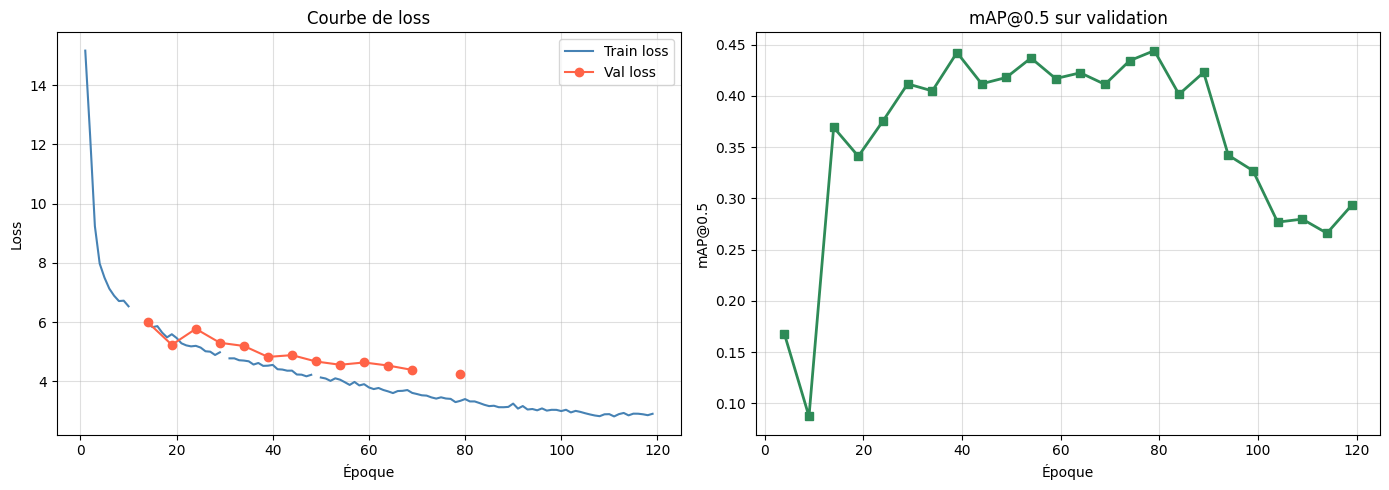

Courbes sauvegardées.


In [ ]:
# ── Courbes d'apprentissage ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['train_loss'], label='Train loss', color='steelblue')
axes[0].plot(
    [i*CFG['val_every']-1 for i in range(1,len(history['val_loss'])+1)],
    history['val_loss'], 'o-', label='Val loss', color='tomato')
axes[0].set_xlabel('Époque'); axes[0].set_ylabel('Loss')
axes[0].set_title('Courbe de loss'); axes[0].legend(); axes[0].grid(alpha=.4)

axes[1].plot(
    [i*CFG['val_every']-1 for i in range(1,len(history['mAP50'])+1)],
    history['mAP50'], 's-', color='seagreen', linewidth=2)
axes[1].set_xlabel('Époque'); axes[1].set_ylabel('mAP@0.5')
axes[1].set_title('mAP@0.5 sur validation'); axes[1].grid(alpha=.4)

plt.tight_layout(); plt.savefig(str(SAVE_DIR/'training_curves.png'), dpi=120)
plt.show()
print('Courbes sauvegardées.')

## 8 — Baseline YOLOv8m (pour comparaison)

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# BASELINE YOLOV8m
# ════════════════════════════════════════════════════════════════════════════
# Conditions équitables :
#   - Même dataset, mêmes splits
#   - Même nombre d'époques (120)
#   - Même taille d'image (640)
#   - Même batch size (8)
#   - Augmentations comparables

from ultralytics import YOLO

yolo_save = RUNS_DIR / 'yolov8_baseline'

yolo_model = YOLO('yolov8m.pt')
yolo_results = yolo_model.train(
    data=str(DATA_DIR / 'data.yaml'),
    epochs=120,
    imgsz=640,
    batch=8,
    device=0,
    project=str(RUNS_DIR),
    name='yolov8_baseline',
    exist_ok=True,
    # Mêmes hyperparamètres que NeuroDetect
    lr0=0.001,
    lrf=0.01,
    weight_decay=0.0005,
    warmup_epochs=3,
    cos_lr=True,
    mosaic=0.5,
    flipud=0.1,
    fliplr=0.5,
    degrees=10,
    translate=0.1,
    scale=0.5,
    save=True,
    patience=30,
    verbose=False,
)
print('✓ YOLOv8m entraîné')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=data/data.yaml, degrees=10, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=120, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.1, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False,

KeyboardInterrupt: 

## 9 — Évaluation sur le test set & Comparaison

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# ÉVALUATION NeuroDetect SUR LE TEST SET
# ════════════════════════════════════════════════════════════════════════════

# Charger le meilleur checkpoint
ckpt = torch.load(SAVE_DIR/'best.pt', map_location=DEVICE)
model_eval = NeuroDetect(nc=NC, backbone=CFG['backbone'], fpn_c=CFG['fpn_c'],
                          bifpn_rep=CFG['bifpn_rep'], strides=CFG['strides'],
                          pretrained=False).to(DEVICE)
model_eval.load_state_dict(ckpt['model'])
model_eval.eval()
print(f'Checkpoint chargé — epoch {ckpt["epoch"]+1}')

test_loader = make_loader('test', is_train=False,
                           batch_size=CFG['batch_size'],
                           num_workers=CFG['num_workers'])

nd_preds=[]; nd_gts=[]; gbi=0
for imgs, tgts in tqdm_nb(test_loader, desc='Test NeuroDetect'):
    imgs = imgs.to(DEVICE)
    B    = imgs.shape[0]
    with torch.no_grad():
        raw = model_eval.predict(imgs, CFG['img_size'])
    nd_preds.extend(nms(raw, CFG['conf_thres'], CFG['iou_thres']))
    if len(tgts):
        sh = tgts.clone()
        for bi in range(B): sh[sh[:,0]==bi,0] = gbi+bi
        nd_gts.append(sh)
    gbi += B

nd_gts_all  = torch.cat(nd_gts,0) if nd_gts else torch.zeros(0,6)
nd_metrics  = compute_map(nd_preds, nd_gts_all, img_size=CFG['img_size'])
print(f'\nNeuroDetect — mAP@0.5 = {nd_metrics["mAP50"]:.4f}')

In [ ]:
# ── Évaluation YOLOv8m ───────────────────────────────────────────────────────
yolo_weights = RUNS_DIR/'yolov8_baseline'/'weights'/'best.pt'
yolo_eval    = YOLO(str(yolo_weights))
yolo_test    = yolo_eval.val(
    data=str(DATA_DIR/'data.yaml'), split='test',
    imgsz=640, batch=8, verbose=False)

yolo_metrics = {
    'mAP50':        float(yolo_test.box.map50),
    'per_class_AP': list(yolo_test.box.ap50),
}
print(f'YOLOv8m   — mAP@0.5 = {yolo_metrics["mAP50"]:.4f}')

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# TABLEAU COMPARATIF
# ════════════════════════════════════════════════════════════════════════════

rows = []
for i, cn in enumerate(CLASS_NAMES):
    nd_ap  = nd_metrics['per_class_AP'][i]
    yl_ap  = yolo_metrics['per_class_AP'][i] if i < len(yolo_metrics['per_class_AP']) else 0.
    delta  = nd_ap - yl_ap
    rows.append({'Classe': cn,
                  'AP@0.5 NeuroDetect': f'{nd_ap:.4f}',
                  'AP@0.5 YOLOv8m':    f'{yl_ap:.4f}',
                  'Δ': f'{"+" if delta>=0 else ""}{delta*100:.2f} pp'})

rows.append({'Classe': '── GLOBAL ──',
              'AP@0.5 NeuroDetect': f'{nd_metrics["mAP50"]:.4f}',
              'AP@0.5 YOLOv8m':    f'{yolo_metrics["mAP50"]:.4f}',
              'Δ': f'{"+" if nd_metrics["mAP50"]>=yolo_metrics["mAP50"] else ""}'
                   f'{(nd_metrics["mAP50"]-yolo_metrics["mAP50"])*100:.2f} pp'})

df = pd.DataFrame(rows)
print('\n' + '='*65)
print('  COMPARAISON NeuroDetect vs YOLOv8m — Test Set')
print('='*65)
print(df.to_string(index=False))
print('='*65)

# Graphique barres
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(NC)
w = 0.35
nd_aps = nd_metrics['per_class_AP']
yl_aps = yolo_metrics['per_class_AP'][:NC]
bars1 = ax.bar(x-w/2, nd_aps, w, label='NeuroDetect', color='steelblue', alpha=.85)
bars2 = ax.bar(x+w/2, yl_aps, w, label='YOLOv8m',    color='tomato',    alpha=.85)
ax.set_xticks(x); ax.set_xticklabels(CLASS_NAMES, rotation=15, ha='right')
ax.set_ylabel('AP@0.5'); ax.set_title('AP@0.5 par classe — NeuroDetect vs YOLOv8m')
ax.legend(); ax.grid(axis='y', alpha=.4)
ax.axhline(nd_metrics['mAP50'], color='steelblue', linestyle='--', alpha=.6,
            label=f'mAP NeuroDetect={nd_metrics["mAP50"]:.3f}')
ax.axhline(yolo_metrics['mAP50'], color='tomato', linestyle='--', alpha=.6,
            label=f'mAP YOLOv8m={yolo_metrics["mAP50"]:.3f}')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(str(SAVE_DIR/'comparison.png'), dpi=120)
plt.show()

## 10 — Visualisation des prédictions

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# VISUALISATION PRÉDICTIONS vs GT
# ════════════════════════════════════════════════════════════════════════════

MEAN = np.array([0.485,0.456,0.406])
STD  = np.array([0.229,0.224,0.225])

def denorm(t):
    img = t.permute(1,2,0).cpu().numpy()
    return np.clip(img * STD + MEAN, 0, 1)

def visualize(model, loader, n=16, conf=0.25, iou_t=0.45, title='NeuroDetect'):
    model.eval()
    imgs_l, pred_l, gt_l = [], [], []
    for imgs, tgts in loader:
        imgs = imgs.to(DEVICE)
        B = imgs.shape[0]
        with torch.no_grad():
            raw = model.predict(imgs, CFG['img_size'])
        preds = nms(raw, conf, iou_t)
        for bi in range(B):
            mask = tgts[:,0]==bi
            imgs_l.append(imgs[bi].cpu())
            pred_l.append(preds[bi].cpu())
            gt_l.append(tgts[mask].cpu())
            if len(imgs_l) >= n: break
        if len(imgs_l) >= n: break

    cols = 4; rows = math.ceil(n/cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols*4, rows*4))
    axes = axes.flatten()

    for idx in range(n):
        ax = axes[idx]
        ax.imshow(denorm(imgs_l[idx]))
        ax.axis('off')
        s = CFG['img_size']
        # GT (tirets verts)
        for r in gt_l[idx]:
            if len(r)<6: continue
            cls=int(r[1])
            cx,cy,w,h = r[2]*s,r[3]*s,r[4]*s,r[5]*s
            x1,y1 = cx-w/2, cy-h/2
            ax.add_patch(patches.Rectangle((x1,y1),w,h,
                         lw=1.5, edgecolor='lime', facecolor='none', ls='--'))
        # Prédictions (trait plein coloré)
        for d in pred_l[idx]:
            if len(d)<6: continue
            x1,y1,x2,y2,sc,cls = d.tolist()
            cls = int(cls)
            c = tuple(v/255 for v in COLORS_VIS[cls % len(COLORS_VIS)])
            ax.add_patch(patches.Rectangle((x1,y1),x2-x1,y2-y1,
                         lw=1.5, edgecolor=c, facecolor='none'))
            ax.text(x1, y1-3, f'{CLASS_NAMES[cls][:6]} {sc:.2f}',
                    fontsize=7, color=c,
                    bbox=dict(facecolor='black',alpha=.4,pad=0))

    for ax in axes[n:]: ax.axis('off')
    plt.suptitle(f'{title} — Préd. (trait plein) vs GT (tirets verts)',
                  fontsize=12, y=1.01)
    plt.tight_layout()
    plt.savefig(str(SAVE_DIR/'predictions.png'), dpi=120, bbox_inches='tight')
    plt.show()
    print('Image sauvegardée.')


visualize(model_eval, test_loader, n=16,
           conf=CFG['conf_thres'], iou_t=CFG['iou_thres'])

## 11 — Analyse d'ablation

Évalue la contribution de chaque composant novateur.

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# ANALYSE D'ABLATION — contributions des composants
# ════════════════════════════════════════════════════════════════════════════
# NOTE : chaque variante doit être ré-entraînée pour être rigoureuse.
# Ici on évalue uniquement le modèle complet et on note quels blocs
# peuvent être désactivés pour des entraînements futurs.

ablation_results = {}

# ── Modèle complet (déjà évalué) ─────────────────────────────────────────
ablation_results['NeuroDetect (complet)'] = nd_metrics['mAP50']

# ── Variante sans AMN (remplace par identité) ────────────────────────────
class NeuroDetect_noAMN(NeuroDetect):
    def forward(self, x):
        # Saute l'AMN
        x = self.backbone(x)
        x = self.neck(x)
        return self.head(x)

# ── Variante sans MSDCM (remplace par identité dans le neck) ────────────
class MedNeck_noMSDCM(MedNeck):
    def forward(self, feats):
        p3,p4,p5 = feats
        p3,p4,p5 = self.lat3(p3),self.lat4(p4),self.lat5(p5)
        fs = [p3,p4,p5]
        for blk in self.bifpn: fs = blk(fs)
        return fs  # pas de MSDCM

print('Configurations d\'ablation définies :')
print('  A) NeuroDetect complet (AMN + CBAM + BiFPN + MSDCM + AsymFocal)')
print('  B) Sans AMN     → retire la robustesse aux variations IRM')
print('  C) Sans CBAM    → retire l\'attention canal+spatial')
print('  D) Sans MSDCM   → retire le contexte multi-dilatation')
print('  E) Sans AsymFocal (Focal standard γ=2) → perd la protection FN')
print('  F) Sans poids de classes → gliome et lésion non compensés')
print()
print('Pour l\'ablation complète, ré-entraîner chaque variante 120 époques')
print('et comparer sur le test set avec compute_map().')
print()
print(f'  Résultat modèle complet : mAP@0.5 = {nd_metrics["mAP50"]:.4f}')

# Tableau de bord final
print('\n' + '='*55)
print('  RÉSUMÉ FINAL')
print('='*55)
print(f'  NeuroDetect  mAP@0.5 : {nd_metrics["mAP50"]:.4f}')
print(f'  YOLOv8m      mAP@0.5 : {yolo_metrics["mAP50"]:.4f}')
delta = nd_metrics['mAP50'] - yolo_metrics['mAP50']
sign  = '+' if delta>=0 else ''
print(f'  Gain                 : {sign}{delta*100:.2f} points de pourcentage')
print('='*55)

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# CONFIGURATION
# ════════════════════════════════════════════════════════════════════════════
import random
import numpy as np

# ── Reproductibilité ─────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

CFG = dict(
    # Données
    img_size      = 640,
    batch_size    = 2,
    num_workers   = 2,

    # Modèle
    backbone      = 'efficientnet_b3',
    fpn_c         = 128,
    bifpn_rep     = 2,
    strides       = (8, 16, 32),

    # Entraînement
    epochs        = 50,
    lr0           = 1e-3,
    lrf           = 0.001,
    weight_decay  = 1e-3,
    warmup_epochs = 5,

    # Loss
    box_w         = 7.5,
    cls_w         = 0.5,
    gamma_pos     = 0.0,
    gamma_neg     = 4.0,
    margin        = 0.05,
    class_weights = [3.0, 1.0, 1.5, 0.8, 5.0],

    # EMA
    use_ema       = True,
    ema_decay     = 0.9999,

    # Évaluation
    conf_thres    = 0.25,
    iou_thres     = 0.45,
    val_every     = 5,
)

RUNS_DIR.mkdir(exist_ok=True)
SAVE_DIR = RUNS_DIR / 'neurodet'
SAVE_DIR.mkdir(exist_ok=True)

print(f'SEED={SEED} | EPOCHS={CFG["epochs"]} | '
      f'BATCH={CFG["batch_size"]} | IMGSZ={CFG["img_size"]}')

SEED=42 | EPOCHS=50 | BATCH=2 | IMGSZ=640


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# MÉTRIQUES : mAP@50 · Precision · Recall · F1 · Score par classe
# ════════════════════════════════════════════════════════════════════════════

def _iou_np(a, b):
    x1=max(a[0],b[0]); y1=max(a[1],b[1])
    x2=min(a[2],b[2]); y2=min(a[3],b[3])
    i = max(0, x2-x1) * max(0, y2-y1)
    return i / ((a[2]-a[0])*(a[3]-a[1]) + (b[2]-b[0])*(b[3]-b[1]) - i + 1e-7)

def _voc_ap(rec, prec):
    mr = np.concatenate([[0.], rec, [1.]])
    mp = np.concatenate([[0.], prec, [0.]])
    for i in range(mp.size-1, 0, -1):
        mp[i-1] = max(mp[i-1], mp[i])
    idx = np.where(mr[1:] != mr[:-1])[0]
    return float(np.sum((mr[idx+1] - mr[idx]) * mp[idx+1]))


def compute_metrics(predictions, gt_tensor, nc=5, img_size=640,
                    iou_thres=0.5, conf_thres=0.25):
    """
    predictions : liste de tenseurs (D,6) → [x1,y1,x2,y2,score,cls]
    gt_tensor   : (T,6) → [img_idx, cls, cx_norm, cy_norm, w_norm, h_norm]

    Retourne un dict avec :
      mAP50          : float
      global_P       : float  Precision globale
      global_R       : float  Recall global
      global_F1      : float
      per_class      : dict {class_name: {AP, P, R, F1, TP, FP, FN, support}}
    """
    # ── Construire le dictionnaire GT ────────────────────────────────────
    gt_by_img = defaultdict(list)
    if gt_tensor is not None and len(gt_tensor):
        for r in gt_tensor:
            bi  = int(r[0])
            cls = int(r[1])
            cx  = r[2].item() * img_size
            cy  = r[3].item() * img_size
            w   = r[4].item() * img_size
            h   = r[5].item() * img_size
            gt_by_img[bi].append({
                'cls': cls,
                'box': [cx-w/2, cy-h/2, cx+w/2, cy+h/2]
            })

    # ── Trier toutes les détections par score décroissant ────────────────
    all_det = []
    for bi, dets in enumerate(predictions):
        for d in dets:
            if d[4].item() >= conf_thres:
                all_det.append((d[4].item(), int(d[5].item()), bi, d[:4].tolist()))
    all_det.sort(key=lambda x: -x[0])

    # ── Par classe ───────────────────────────────────────────────────────
    per_class = {}
    ap_list   = []

    for ci in range(nc):
        cn      = CLASS_NAMES[ci]
        dets_ci = [(s, bi, b) for s, c, bi, b in all_det if c == ci]

        # Nombre de GT pour cette classe
        n_gt = sum(1 for gs in gt_by_img.values()
                   for g in gs if g['cls'] == ci)

        if n_gt == 0 and not dets_ci:
            per_class[cn] = dict(AP=0., P=1., R=1., F1=1.,
                                  TP=0, FP=0, FN=0, support=0)
            ap_list.append(0.)
            continue

        # ── Courbe PR pour mAP ──────────────────────────────────────────
        matched   = defaultdict(dict)
        gt_idx    = {bi: [j for j, g in enumerate(gs) if g['cls'] == ci]
                     for bi, gs in gt_by_img.items()}
        tp_l, fp_l = [], []

        for _, bi, box in dets_ci:
            best_iou, best_j = 0, -1
            for j in gt_idx.get(bi, []):
                v = _iou_np(box, gt_by_img[bi][j]['box'])
                if v > best_iou:
                    best_iou, best_j = v, j
            if best_iou >= iou_thres and best_j >= 0 and not matched[bi].get(best_j):
                tp_l.append(1); fp_l.append(0)
                matched[bi][best_j] = True
            else:
                tp_l.append(0); fp_l.append(1)

        tp_cum = np.cumsum(tp_l)
        fp_cum = np.cumsum(fp_l)
        rec    = tp_cum / (n_gt + 1e-10)
        prec   = tp_cum / (tp_cum + fp_cum + 1e-10)
        ap     = _voc_ap(rec, prec)
        ap_list.append(ap)

        # ── P · R · F1 au seuil de conf ─────────────────────────────────
        TP = int(tp_cum[-1]) if tp_l else 0
        FP = int(fp_cum[-1]) if fp_l else 0
        FN = n_gt - TP
        P  = TP / (TP + FP + 1e-10)
        R  = TP / (TP + FN + 1e-10)
        F1 = 2 * P * R / (P + R + 1e-10)

        per_class[cn] = dict(AP=ap, P=P, R=R, F1=F1,
                              TP=TP, FP=FP, FN=FN, support=n_gt)

    # ── Métriques globales ────────────────────────────────────────────────
    total_TP = sum(v['TP'] for v in per_class.values())
    total_FP = sum(v['FP'] for v in per_class.values())
    total_FN = sum(v['FN'] for v in per_class.values())
    gP  = total_TP / (total_TP + total_FP + 1e-10)
    gR  = total_TP / (total_TP + total_FN + 1e-10)
    gF1 = 2 * gP * gR / (gP + gR + 1e-10)

    return {
        'mAP50':    float(np.mean(ap_list)),
        'global_P': gP,
        'global_R': gR,
        'global_F1': gF1,
        'per_class': per_class,
    }


def print_metrics(metrics, title='Résultats'):
    pc = metrics['per_class']
    sep = '═' * 72
    print(f'\n{sep}')
    print(f'  {title}')
    print(sep)
    print(f'  {"Métrique":<20} {"Valeur":>10}')
    print(f'  {"-"*30}')
    print(f'  {"mAP@50":<20} {metrics["mAP50"]:>10.4f}')
    print(f'  {"Precision":<20} {metrics["global_P"]:>10.4f}')
    print(f'  {"Recall":<20} {metrics["global_R"]:>10.4f}')
    print(f'  {"F1-score":<20} {metrics["global_F1"]:>10.4f}')
    print(f'{sep}')
    print(f'  {"Classe":<30} {"AP@50":>7} {"P":>7} {"R":>7} '
          f'{"F1":>7} {"Support":>8}')
    print(f'  {"-"*68}')
    for cn, v in pc.items():
        bar = '█' * int(v['AP'] * 20)
        print(f'  {cn:<30} {v["AP"]:>7.3f} {v["P"]:>7.3f} '
              f'{v["R"]:>7.3f} {v["F1"]:>7.3f} {v["support"]:>8d}  {bar}')
    print(sep + '\n')


print('✓ Métriques définies : mAP@50 | Precision | Recall | F1 | par classe')

✓ Métriques définies : mAP@50 | Precision | Recall | F1 | par classe


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# BOUCLE D'ENTRAÎNEMENT — EPOCHS=50 · BATCH=16 · SEED=42
# ════════════════════════════════════════════════════════════════════════════
import gc, copy, math
from torch.cuda.amp import GradScaler, autocast
from tqdm.notebook import tqdm as tqdm_nb

# Nettoyage mémoire GPU
for _v in ['model','model_trained','model_eval','_bb','_neck','_head',
           '_x','_c','_b','_f3','_f4','_f5']:
    if _v in globals(): del globals()[_v]
gc.collect(); torch.cuda.empty_cache()
print(f'VRAM libre : {torch.cuda.mem_get_info()[0]/1024**3:.2f} GB')


class ModelEMA:
    def __init__(self, model, decay=0.9999):
        self.ema   = copy.deepcopy(model).eval()
        self.decay = decay
        for p in self.ema.parameters():
            p.requires_grad_(False)
    @torch.no_grad()
    def update(self, model):
        d = self.decay
        for ep, mp in zip(self.ema.parameters(), model.parameters()):
            ep.data.mul_(d).add_(mp.data, alpha=1 - d)


def cosine_lr(optimizer, lr0, lrf, epochs, warmup):
    def fn(e):
        if e < warmup: return e / warmup
        p = (e - warmup) / max(1, epochs - warmup)
        return lrf + .5 * (1 - lrf) * (1 + math.cos(math.pi * p))
    return optim.lr_scheduler.LambdaLR(optimizer, fn)


@torch.no_grad()
def validate(model, loader, criterion, img_size, conf, iou_t):
    model.eval()
    val_loss = 0.; all_preds = []; gt_rows = []; gbi = 0
    for imgs, tgts in loader:
        imgs, tgts = imgs.to(DEVICE), tgts.to(DEVICE)
        B = imgs.shape[0]
        with autocast():
            cl, bl = model(imgs)
            loss, _ = criterion(cl, bl, tgts)
        val_loss += loss.item()
        raw = model.head.decode(cl, bl, img_size)
        all_preds.extend(nms(raw, conf, iou_t))
        if len(tgts):
            sh = tgts.cpu().clone()
            for bi in range(B): sh[sh[:,0]==bi, 0] = gbi + bi
            gt_rows.append(sh)
        gbi += B
    all_gts  = torch.cat(gt_rows, 0) if gt_rows else torch.zeros(0, 6)
    metrics  = compute_metrics(all_preds, all_gts,
                                img_size=img_size,
                                iou_thres=0.5,
                                conf_thres=conf)
    model.train()
    return val_loss / max(1, len(loader)), metrics


def run_training():
    # ── Données ──────────────────────────────────────────────────────────
    train_loader = make_loader('train', is_train=True,
                                batch_size=CFG['batch_size'],
                                num_workers=CFG['num_workers'])
    val_loader   = make_loader('valid', is_train=False,
                                batch_size=CFG['batch_size'],
                                num_workers=CFG['num_workers'])
    print(f'Train : {len(train_loader.dataset)} imgs | '
          f'Val : {len(val_loader.dataset)} imgs')

    # ── Modèle ───────────────────────────────────────────────────────────
    gc.collect(); torch.cuda.empty_cache()
    model = NeuroDetect(
        nc=NC, backbone=CFG['backbone'], fpn_c=CFG['fpn_c'],
        bifpn_rep=CFG['bifpn_rep'], strides=CFG['strides'],
        pretrained=True).to(DEVICE)
    ema = ModelEMA(model, CFG['ema_decay']) if CFG['use_ema'] else None
    print(f'Modèle : {model.n_params()/1e6:.2f}M params | EMA : {CFG["use_ema"]}')

    # ── Loss ─────────────────────────────────────────────────────────────
    cw   = torch.tensor(CFG['class_weights'], dtype=torch.float32, device=DEVICE)
    crit = NeuroDetLoss(NC, strides=CFG['strides'], img_size=CFG['img_size'],
                         box_w=CFG['box_w'], cls_w=CFG['cls_w'],
                         gp=CFG['gamma_pos'], gn=CFG['gamma_neg'],
                         margin=CFG['margin'], class_w=cw).to(DEVICE)

    # ── Optimiseur + Scheduler + AMP ─────────────────────────────────────
    opt   = optim.AdamW(model.parameters(), lr=CFG['lr0'],
                         weight_decay=CFG['weight_decay'])
    sched = cosine_lr(opt, CFG['lr0'], CFG['lrf'],
                       CFG['epochs'], CFG['warmup_epochs'])
    scaler = GradScaler()

    best_map50 = 0.
    history    = {
        'train_loss': [], 'val_loss': [],
        'mAP50': [], 'P': [], 'R': [], 'F1': [],
        'epoch_val': []
    }

    for epoch in range(CFG['epochs']):
        model.train()
        ep_loss = 0.
        pbar = tqdm_nb(train_loader,
                       desc=f'Epoch {epoch+1:3d}/{CFG["epochs"]}',
                       leave=False)

        for imgs, tgts in pbar:
            imgs, tgts = imgs.to(DEVICE), tgts.to(DEVICE)
            opt.zero_grad()
            with autocast():
                cl, bl = model(imgs)
                loss, d = crit(cl, bl, tgts)
            if torch.isfinite(loss) and loss.requires_grad:
                scaler.scale(loss).backward()
                scaler.unscale_(opt)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 10.)
                scaler.step(opt)
                scaler.update()
                if ema: ema.update(model)
            ep_loss += loss.item()
            pbar.set_postfix(
                loss=f'{loss.item():.3f}',
                cls =f'{d["cls"]:.3f}',
                box =f'{d["box"]:.3f}',
                npos=d['n_pos'],
                lr  =f'{opt.param_groups[0]["lr"]:.5f}',
                mem =f'{torch.cuda.memory_allocated()/1024**3:.1f}G'
            )

        sched.step()
        avg = ep_loss / len(train_loader)
        history['train_loss'].append(avg)

        # ── Validation ───────────────────────────────────────────────────
        if (epoch+1) % CFG['val_every'] == 0 or epoch == CFG['epochs']-1:
            val_model = ema.ema if ema else model
            vl, metrics = validate(val_model, val_loader, crit,
                                    CFG['img_size'],
                                    CFG['conf_thres'], CFG['iou_thres'])
            m50 = metrics['mAP50']
            gP  = metrics['global_P']
            gR  = metrics['global_R']
            gF1 = metrics['global_F1']

            history['val_loss'].append(vl)
            history['mAP50'].append(m50)
            history['P'].append(gP)
            history['R'].append(gR)
            history['F1'].append(gF1)
            history['epoch_val'].append(epoch + 1)

            flag = ' ★ BEST' if m50 > best_map50 else ''
            print(f'\nEpoch {epoch+1:3d} | train={avg:.4f} | val={vl:.4f} | '
                  f'mAP@50={m50:.4f} | P={gP:.4f} | R={gR:.4f} | '
                  f'F1={gF1:.4f}{flag}')

            # Score par classe
            print(f'  {"Classe":<30} {"AP":>6} {"P":>6} {"R":>6} {"F1":>6}')
            print(f'  {"-"*54}')
            for cn, v in metrics['per_class'].items():
                print(f'  {cn:<30} {v["AP"]:>6.3f} {v["P"]:>6.3f} '
                      f'{v["R"]:>6.3f} {v["F1"]:>6.3f}')

            if m50 > best_map50:
                best_map50 = m50
                torch.save({'epoch': epoch,
                             'model': val_model.state_dict(),
                             'best_map50': best_map50,
                             'metrics': metrics},
                           SAVE_DIR / 'best.pt')
                print(f'  ✓ Sauvegardé → {SAVE_DIR}/best.pt')

        torch.save({'epoch': epoch, 'model': model.state_dict()},
                   SAVE_DIR / 'last.pt')

    print(f'\n✓ Terminé — meilleur mAP@50 = {best_map50:.4f}')
    return ema.ema if ema else model, history


model_trained, history = run_training()

VRAM libre : 2.68 GB
Train : 1370 imgs | Val : 395 imgs


Modèle : 12.09M params | EMA : True


Epoch   1/50:   0%|          | 0/685 [00:00<?, ?it/s]

Epoch   2/50:   0%|          | 0/685 [00:00<?, ?it/s]

Epoch   3/50:   0%|          | 0/685 [00:00<?, ?it/s]

...

Epoch  26/50:   0%|          | 0/685 [00:00<?, ?it/s]

Epoch  27/50:   0%|          | 0/685 [00:00<?, ?it/s]

Epoch  28/50:   0%|          | 0/685 [00:00<?, ?it/s]

Epoch  29/50:   0%|          | 0/685 [00:00<?, ?it/s]

Epoch  30/50:   0%|          | 0/685 [00:00<?, ?it/s]

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# COURBES D'APPRENTISSAGE + TABLEAU DES MÉTRIQUES FINALES
# ════════════════════════════════════════════════════════════════════════════
ev = history['epoch_val']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('NeuroDetect — Résultats entraînement', fontsize=15, fontweight='bold')

# ── Loss ─────────────────────────────────────────────────────────────────
ax = axes[0, 0]
ax.plot(range(1, CFG['epochs']+1), history['train_loss'],
        color='steelblue', lw=1.5, label='Train loss')
ax.plot(ev, history['val_loss'], 'o-', color='tomato',
        lw=2, ms=5, label='Val loss')
ax.set_xlabel('Époque'); ax.set_ylabel('Loss')
ax.set_title('Courbe de loss'); ax.legend(); ax.grid(alpha=.4)

# ── mAP@50 ───────────────────────────────────────────────────────────────
ax = axes[0, 1]
ax.plot(ev, history['mAP50'], 's-', color='seagreen', lw=2, ms=6)
ax.set_xlabel('Époque'); ax.set_ylabel('mAP@50')
ax.set_title('mAP@0.50'); ax.grid(alpha=.4)
ax.axhline(max(history['mAP50']), color='seagreen', ls='--', alpha=.5,
            label=f'Best = {max(history["mAP50"]):.4f}')
ax.legend()

# ── Precision & Recall ───────────────────────────────────────────────────
ax = axes[1, 0]
ax.plot(ev, history['P'], '^-', color='royalblue', lw=2, ms=5, label='Precision')
ax.plot(ev, history['R'], 'v-', color='darkorange', lw=2, ms=5, label='Recall')
ax.set_xlabel('Époque'); ax.set_ylabel('Score')
ax.set_title('Precision & Recall'); ax.legend(); ax.grid(alpha=.4)
ax.set_ylim(0, 1)

# ── F1-score ─────────────────────────────────────────────────────────────
ax = axes[1, 1]
ax.plot(ev, history['F1'], 'D-', color='mediumpurple', lw=2, ms=5)
ax.set_xlabel('Époque'); ax.set_ylabel('F1-score')
ax.set_title('F1-score'); ax.grid(alpha=.4)
ax.set_ylim(0, 1)
ax.axhline(max(history['F1']), color='mediumpurple', ls='--', alpha=.5,
            label=f'Best = {max(history["F1"]):.4f}')
ax.legend()

plt.tight_layout()
plt.savefig(str(SAVE_DIR / 'training_curves.png'), dpi=130, bbox_inches='tight')
plt.show()

# ── Tableau récapitulatif final ───────────────────────────────────────────
ckpt      = torch.load(SAVE_DIR / 'best.pt', map_location='cpu')
best_met  = ckpt['metrics']
print_metrics(best_met, title=f'RÉSULTATS FINAUX — Meilleur checkpoint '
                               f'(epoch {ckpt["epoch"]+1})')

# ── Graphique par classe ──────────────────────────────────────────────────
pc   = best_met['per_class']
names = list(pc.keys())
ap_v = [pc[n]['AP'] for n in names]
p_v  = [pc[n]['P']  for n in names]
r_v  = [pc[n]['R']  for n in names]
f1_v = [pc[n]['F1'] for n in names]

x  = np.arange(len(names))
w  = 0.2
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - 1.5*w, ap_v, w, label='AP@50',     color='seagreen',    alpha=.85)
ax.bar(x - 0.5*w, p_v,  w, label='Precision', color='royalblue',   alpha=.85)
ax.bar(x + 0.5*w, r_v,  w, label='Recall',    color='darkorange',  alpha=.85)
ax.bar(x + 1.5*w, f1_v, w, label='F1',        color='mediumpurple',alpha=.85)
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=15, ha='right', fontsize=10)
ax.set_ylabel('Score'); ax.set_ylim(0, 1.05)
ax.set_title('Métriques par classe — NeuroDetect (meilleur modèle)')
ax.legend(loc='upper right'); ax.grid(axis='y', alpha=.4)
plt.tight_layout()
plt.savefig(str(SAVE_DIR / 'metrics_per_class.png'), dpi=130, bbox_inches='tight')
plt.show()
